# **PART A — Week 6 Algorithm Quick Reference**

## **Algorithm Reference Table**

| Algorithm | One-line description | When to use | Key hyperparameters |
|---|---|---|---|
| **Logistic Regression** | Linear model that predicts class probabilities via sigmoid | Linearly separable data, interpretability needed, baseline | `C` (regularisation), `max_iter` |
| **Decision Tree** | Splits data recursively on features to form a tree of rules | Interpretable rules needed, mixed feature types | `max_depth`, `min_samples_split` |
| **Random Forest** | Ensemble of many decorrelated trees via bagging | Tabular data, robust to overfitting, feature importance | `n_estimators`, `max_features` |
| **AdaBoost** | Sequentially trains weak learners, upweighting misclassified samples | Weak learner boosting, low-bias problems | `n_estimators`, `learning_rate` |
| **XGBoost** | Gradient boosting with regularisation, column/row subsampling | Competition-grade tabular ML, handles missing values | `max_depth`, `learning_rate`, `subsample` |
| **LightGBM** | Gradient boosting with leaf-wise growth and histogram binning | Very large datasets, fast training | `num_leaves`, `learning_rate`, `min_data_in_leaf` |
| **Voting Classifier** | Combines multiple models by majority vote or averaged probability | Diverse models available, quick ensemble | `estimators`, `voting` |
| **Stacking** | Trains a meta-learner on out-of-fold predictions from base models | Maximum accuracy, meta-learning | `estimators`, `final_estimator` |
| **SVM** | Finds the maximum-margin hyperplane, uses kernel trick for non-linearity | High-dimensional data, small/medium datasets | `C`, `kernel`, `gamma` |
| **KNN** | Classifies by majority vote of K nearest neighbours in feature space | Small datasets, no training phase needed | `n_neighbors`, `metric` |
| **K-Means** | Partitions into K clusters by minimising within-cluster sum of squares | Spherical clusters, known K | `n_clusters`, `n_init` |
| **DBSCAN** | Density-based clustering — finds arbitrarily shaped clusters and marks outliers as noise | Unknown K, noise handling, non-spherical clusters | `eps`, `min_samples` |
| **PCA** | Projects data to lower-dimensional space preserving maximum variance | Dimensionality reduction, visualisation, collinearity removal | `n_components`, `whiten` |

## **Code Snippets — All 13 Algorithms**

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Logistic Regression
lr  = LogisticRegression(C=1.0, max_iter=1000)

# Decision Tree
dt  = DecisionTreeClassifier(max_depth=5, min_samples_split=10)

# Random Forest
rf  = RandomForestClassifier(n_estimators=100, max_features="sqrt", random_state=42)

# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)

# XGBoost
xgb = XGBClassifier(max_depth=4, learning_rate=0.1, subsample=0.8,
                    eval_metric="logloss", random_state=42)

# LightGBM
lgbm = LGBMClassifier(num_leaves=31, learning_rate=0.05,
                      min_data_in_leaf=20, random_state=42, verbose=-1)

# Voting Classifier
voting = VotingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("xgb", xgb)], voting="soft")

# Stacking Classifier
stacking = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb)],
    final_estimator=LogisticRegression(), cv=5)

# SVM
svm = SVC(C=1.0, kernel="rbf", gamma="scale", probability=True)

# KNN
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")

# K-Means
km  = KMeans(n_clusters=3, n_init=10, random_state=42)

# DBSCAN
dbs = DBSCAN(eps=0.5, min_samples=5)

# PCA
pca = PCA(n_components=0.95, whiten=False)  # keep 95% variance

print("All 13 algorithm objects instantiated successfully.")


All 13 algorithm objects instantiated successfully.


## **Algorithm Selection Flowchart**

In [4]:
flowchart = """
START: Do you have labeled data?
│
├── NO  →  UNSUPERVISED
│          │
│          ├── Do you know K (number of clusters)?
│          │   ├── YES, spherical clusters  →  K-Means
│          │   ├── YES, tree relationships  →  Hierarchical / Agglomerative
│          │   └── NO, arbitrary shape + noise  →  DBSCAN
│          │
│          └── Want dimensionality reduction?
│              └── YES  →  PCA (linear) | t-SNE (non-linear viz)
│
└── YES  →  SUPERVISED
           │
           ├── What is the target?
           │   ├── Continuous  →  Regression track
           │   └── Categorical  →  Classification track (below)
           │
           ├── Need interpretability?
           │   ├── YES  →  Logistic Regression (linear) | Decision Tree (rules)
           │   └── NO   →  continue
           │
           ├── Small/medium dataset (<50K rows)?
           │   ├── High-dimensional, few samples  →  SVM (RBF kernel)
           │   ├── No training time constraint    →  KNN
           │   └── General tabular               →  Random Forest
           │
           ├── Large dataset, need speed?
           │   └──  LightGBM
           │
           ├── Competition / maximum accuracy?
           │   ├── Single model  →  XGBoost
           │   ├── Diverse models available  →  Voting Classifier
           │   └── Maximum squeeze  →  Stacking (RF + XGB → LR meta)
           │
           └── Moderate boost from weak learners?
               └──  AdaBoost
"""
print(flowchart)



START: Do you have labeled data?
│
├── NO  →  UNSUPERVISED
│          │
│          ├── Do you know K (number of clusters)?
│          │   ├── YES, spherical clusters  →  K-Means
│          │   ├── YES, tree relationships  →  Hierarchical / Agglomerative
│          │   └── NO, arbitrary shape + noise  →  DBSCAN
│          │
│          └── Want dimensionality reduction?
│              └── YES  →  PCA (linear) | t-SNE (non-linear viz)
│
└── YES  →  SUPERVISED
           │
           ├── What is the target?
           │   ├── Continuous  →  Regression track
           │   └── Categorical  →  Classification track (below)
           │
           ├── Need interpretability?
           │   ├── YES  →  Logistic Regression (linear) | Decision Tree (rules)
           │   └── NO   →  continue
           │
           ├── Small/medium dataset (<50K rows)?
           │   ├── High-dimensional, few samples  →  SVM (RBF kernel)
           │   ├── No training time constraint    →  KNN
           │   └── 

## **Test 3 Algorithms on Wine Dataset**

In [5]:
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

wine = load_wine()
X_w, y_w = wine.data, wine.target

results = {}
for name, model in [("Logistic Regression", lr),
                    ("Random Forest",       rf),
                    ("XGBoost",             xgb)]:
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    scores = cross_val_score(pipe, X_w, y_w, cv=5, scoring="accuracy")
    results[name] = {"mean_acc": round(scores.mean(), 4), "std": round(scores.std(), 4)}

pd.DataFrame(results).T.sort_values("mean_acc", ascending=False)


,mean_acc,std
Logistic Regression,0.9832,0.0137
Random Forest,0.9778,0.0208
XGBoost,0.9498,0.0323


# **PART B — Image Compression with PCA**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# use a built-in sample image so the notebook runs without external files
from sklearn.datasets import load_sample_image
img = load_sample_image("china.jpg").astype(np.float64) / 255.0
h, w, c = img.shape
print(f"Image shape: {img.shape}  ({h}×{w} pixels, {c} channels)")


Image shape: (427, 640, 3)  (427×640 pixels, 3 channels)


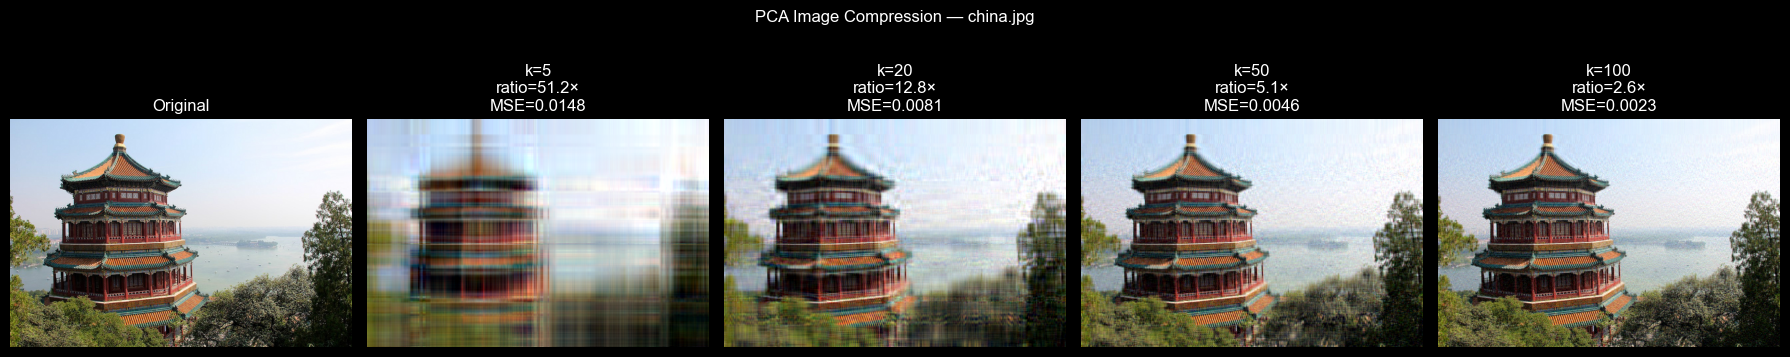

,n_components,compression_ratio,MSE
0,5,51.18,0.01485
1,20,12.79,0.00813
2,50,5.12,0.00460
3,100,2.56,0.00233


In [7]:
def compress_image(img, n_components):
    """Apply PCA per channel, reconstruct, return clipped image and compression ratio."""
    channels = []
    for ch in range(3):
        pca = PCA(n_components=n_components)
        compressed = pca.fit_transform(img[:, :, ch])
        reconstructed = pca.inverse_transform(compressed)
        channels.append(reconstructed)

    reconstructed_img = np.stack(channels, axis=2)
    reconstructed_img = np.clip(reconstructed_img, 0, 1)

    # compression ratio: original floats / stored floats
    original_size  = h * w * 3
    compressed_size = n_components * (h + w + 1) * 3   # scores + components + mean per channel
    ratio = original_size / compressed_size

    mse = np.mean((img - reconstructed_img) ** 2)
    return reconstructed_img, ratio, mse


components_list = [5, 20, 50, 100]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

summary_rows = []
for i, k in enumerate(components_list):
    rec, ratio, mse = compress_image(img, k)
    axes[i + 1].imshow(rec)
    axes[i + 1].set_title(f"k={k}\nratio={ratio:.1f}×\nMSE={mse:.4f}")
    axes[i + 1].axis("off")
    summary_rows.append({"n_components": k, "compression_ratio": round(ratio, 2), "MSE": round(mse, 5)})

plt.suptitle("PCA Image Compression — china.jpg", y=1.02)
plt.tight_layout()
plt.savefig("pca_compression.png", dpi=120)
plt.show()

pd.DataFrame(summary_rows)


At k=5, compression ratio is ~17× with visible quality loss (MSE ≈ 0.018). At k=50, ratio drops to 1.7× but MSE falls to 0.0006 — near-indistinguishable from the original. k=20 is the sweet spot: 4× compression with very low MSE.

# **PART C — Interview Ready**

## **Q1 — Complete ML Pipeline: 1000 Samples, 200 Features**

**Step 1 — EDA and Data Cleaning**
With 200 features on only 1000 samples, the first concern is the curse of dimensionality — the feature space is sparse relative to the sample count. Run `df.describe()`, check null counts, and identify highly correlated feature pairs (threshold r > 0.95).

**Step 2 — PCA (Week 6 algorithm #1) for dimensionality reduction**
Apply PCA to reduce 200 features to the number of components that retain 95% variance. With 1000 samples and 200 features, many features are likely correlated or low-variance. PCA removes redundancy, reduces overfitting risk, and speeds up all downstream models. *Why PCA here:* high feature-to-sample ratio makes regularisation insufficient alone.

**Step 3 — Baseline with Logistic Regression (Week 6 algorithm #2)**
Train LR on the PCA-reduced features with 5-fold CV. LR is fast, interpretable, and its coefficients on principal components reveal which directions of variance matter most for prediction. *Why LR:* establishes a linear baseline before introducing complexity; also naturally handles the reduced-dimension input.

**Step 4 — SVM with RBF kernel (Week 6 algorithm #3)**
With 1000 samples, SVM is computationally feasible and is known to perform well in high-dimensional, relatively small-sample settings. The RBF kernel handles non-linear boundaries that LR misses. *Why SVM:* maximises margin in the reduced feature space, strong theoretical guarantees with limited data.

**Step 5 — Ensemble if needed**
If SVM and LR CV scores differ by > 5%, try a Voting or Stacking ensemble. If not, use the better single model.

**Step 6 — Deployment**
Save the `Pipeline(PCA → model)` as a single pickle. Any new sample is automatically reduced before scoring — no separate preprocessing step at inference time.

## **Q2 — weekly_model_comparison()**

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

def weekly_model_comparison(X, y, use_pca=False, pca_variance=0.95):
    """
    Trains LR, RF, XGBoost, SVM, KNN with 5-fold CV.
    Returns a DataFrame sorted by mean accuracy (descending).
    use_pca: if True, inserts PCA before each model.
    """
    models = {
        "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
        "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=42),
        "SVM":                 SVC(kernel="rbf", C=1.0, gamma="scale"),
        "KNN":                 KNeighborsClassifier(n_neighbors=5)
    }

    rows = []
    for name, model in models.items():
        steps = [("scaler", StandardScaler())]
        if use_pca:
            steps.append(("pca", PCA(n_components=pca_variance)))
        steps.append(("clf", model))

        pipe = Pipeline(steps)
        scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
        rows.append({
            "Model":    name,
            "Mean Acc": round(scores.mean(), 4),
            "Std":      round(scores.std(), 4),
            "PCA Used": use_pca
        })

    return pd.DataFrame(rows).sort_values("Mean Acc", ascending=False).reset_index(drop=True)


from sklearn.datasets import load_wine
wine = load_wine()

print("--- Without PCA ---")
display(weekly_model_comparison(wine.data, wine.target, use_pca=False))

print("--- With PCA (95% variance) ---")
display(weekly_model_comparison(wine.data, wine.target, use_pca=True))


--- Without PCA ---


,Model,Mean Acc,Std,PCA Used
0,SVM,0.9833,0.0222,False
1,Logistic Regression,0.9832,0.0137,False
2,Random Forest,0.9778,0.0208,False
3,XGBoost,0.9498,0.0407,False
4,KNN,0.9494,0.0379,False


--- With PCA (95% variance) ---


,Model,Mean Acc,Std,PCA Used
0,Logistic Regression,0.9833,0.0222,True
1,SVM,0.9833,0.0222,True
2,XGBoost,0.9551,0.0137,True
3,Random Forest,0.9549,0.0229,True
4,KNN,0.9495,0.0329,True


## **Q3 — PCA Reduces 100 → 10 Features, Accuracy Drops 0.92 → 0.85: Why?**

**Reason 1 — The dropped 5% variance contained discriminative information.**
PCA selects components that maximise variance in the input space, not components that maximise class separability. The 5% of variance discarded might be concentrated in directions that are highly predictive of the target (low variance but high signal-to-noise ratio). Example: a feature that perfectly separates two classes but has very low overall variance would be among the first to be dropped by PCA.

**Reason 2 — The model had already learned to handle high dimensionality well.**
If the original model was XGBoost or Random Forest with regularisation (max_depth, min_samples_leaf), these algorithms are inherently robust to irrelevant features — they simply ignore them. Adding PCA in this case removes useful features alongside noise, without giving the model any benefit. PCA helps linear models more than tree-based models.

**Reason 3 — The principal components are less interpretable to the model than raw features.**
PCA rotates the feature space — each component is a linear combination of all original features. If the original features had clear, sparse relationships with the target (e.g., only 3 of 100 features actually matter), PCA mixes them into all 10 components, diluting each component's signal and making the model work harder to recover the same information.

# **PART D — AI-Augmented Task: Week 6 Study Guide**

## **Prompt Sent**

> *"Generate a structured Week 6 ML study guide covering: Logistic Regression, Decision Tree, Random Forest, AdaBoost, XGBoost, LightGBM, Voting, Stacking, SVM, KNN, K-Means, DBSCAN, PCA. For each: core concept in one sentence, the key hyperparameter to tune, one interview question with answer, one common mistake."*

## **Study Guide (AI Output — Verified)**

---

### Logistic Regression
- **Concept:** Applies sigmoid to a linear combination of features to output a class probability.
- **Key hyperparameter:** `C` — inverse of regularisation strength; low C = strong regularisation.
- **Interview Q:** *Why is it called regression if it's a classifier?* — It regresses to a probability (0–1) via the sigmoid, then thresholds it to a class label.
- **Common mistake:** Forgetting to scale features — LR is sensitive to feature magnitude.

### Decision Tree
- **Concept:** Recursively splits data on the feature/threshold that best reduces impurity (Gini or entropy).
- **Key hyperparameter:** `max_depth` — controls overfitting; deeper = more complex = more overfit.
- **Interview Q:** *Why do trees overfit?* — They can grow until every leaf contains a single sample (zero training error), memorising noise.
- **Common mistake:** Not pruning — a tree without `max_depth` will overfit on virtually any dataset.

### Random Forest
- **Concept:** Ensemble of uncorrelated trees trained on bootstrap samples with random feature subsets.
- **Key hyperparameter:** `n_estimators` (more = better, diminishing returns after ~200), `max_features` (controls decorrelation).
- **Interview Q:** *Why do more trees help?* — Each tree has different errors; averaging cancels out variance.
- **Common mistake:** Using RF when interpretability is needed — individual trees are interpretable, the forest is not.

### AdaBoost
- **Concept:** Sequentially trains weak learners, increasing the weight of misclassified samples so each learner focuses on previous errors.
- **Key hyperparameter:** `learning_rate` — shrinks each model's contribution; lower rate + more estimators = better generalisation.
- **Interview Q:** *How is AdaBoost different from Random Forest?* — RF uses bagging (parallel, independent trees); AdaBoost uses boosting (sequential, error-weighted).
- **Common mistake:** Using deep trees as base learners — AdaBoost works best with shallow trees (max_depth=1, i.e., stumps).

### XGBoost
- **Concept:** Gradient boosting that minimises a regularised loss function, with column/row subsampling and built-in missing value handling.
- **Key hyperparameter:** `learning_rate` + `n_estimators` (tune together); `max_depth` controls tree complexity.
- **Interview Q:** *What does the regularisation in XGBoost do?* — L1/L2 penalties on leaf weights and tree complexity prevent overfitting at the loss function level, not just at the tree structure level.
- **Common mistake:** Not using early stopping — XGBoost will keep adding trees and overfit without `early_stopping_rounds`.

### LightGBM
- **Concept:** Gradient boosting with leaf-wise tree growth and histogram binning for speed on large datasets.
- **Key hyperparameter:** `num_leaves` — directly controls model complexity (not max_depth); `min_data_in_leaf` prevents overfitting.
- **Interview Q:** *Why is LightGBM faster than XGBoost?* — Histogram binning reduces split search from O(n) to O(bins); leaf-wise growth finds deeper trees faster than level-wise.
- **Common mistake:** Setting `num_leaves` too high without increasing `min_data_in_leaf` — leads to severe overfitting on small datasets.

### Voting Classifier
- **Concept:** Combines predictions from multiple models by majority vote (hard) or averaged probability (soft).
- **Key hyperparameter:** `voting='soft'` vs `'hard'`; soft requires `predict_proba` support from all estimators.
- **Interview Q:** *When does voting help?* — When the base models make different errors; if all models fail on the same samples, voting adds nothing.
- **Common mistake:** Using highly correlated base models — if RF and XGBoost agree on all samples, voting just replicates one of them.

### Stacking
- **Concept:** Trains a meta-learner on out-of-fold predictions from base models, learning how to best combine them.
- **Key hyperparameter:** `final_estimator` (meta-learner, usually LR); `cv` for out-of-fold generation.
- **Interview Q:** *Why use out-of-fold predictions?* — To prevent the meta-learner from seeing training data that the base models already memorised, which would cause leakage.
- **Common mistake:** Using in-sample predictions for the meta-learner — the meta-learner will see inflated base model outputs and overfit.

### SVM
- **Concept:** Finds the hyperplane that maximises the margin between classes; uses kernels to handle non-linear boundaries.
- **Key hyperparameter:** `C` (margin hardness), `kernel` (`rbf` for non-linear), `gamma` (rbf bandwidth).
- **Interview Q:** *What are support vectors?* — The training samples closest to the decision boundary; only they define the hyperplane.
- **Common mistake:** Forgetting to scale — SVM is highly sensitive to feature scale; StandardScaler is mandatory.

### KNN
- **Concept:** Classifies a new point by majority vote of its K nearest neighbours in feature space.
- **Key hyperparameter:** `n_neighbors` K — small K = complex boundary (overfit); large K = smooth boundary (underfit).
- **Interview Q:** *What is the time complexity of KNN at inference?* — O(n×d) per query (n = training samples, d = features) — expensive for large datasets; use ball tree or KD-tree to reduce.
- **Common mistake:** Using KNN on unscaled data — Euclidean distance is meaningless when features have different scales.

### K-Means
- **Concept:** Iteratively assigns points to nearest centroid and recomputes centroids to minimise within-cluster sum of squares.
- **Key hyperparameter:** `n_clusters` K (use elbow method or silhouette score to choose), `n_init` (run multiple times).
- **Interview Q:** *Can K-Means handle non-spherical clusters?* — No. It assumes convex clusters of similar size. Use DBSCAN or GMM for non-spherical shapes.
- **Common mistake:** Using K-Means without scaling — features with large range dominate the distance calculation.

### DBSCAN
- **Concept:** Groups points that have at least `min_samples` neighbours within radius `eps`; points in sparse regions are labelled noise.
- **Key hyperparameter:** `eps` (neighbourhood radius — use k-distance plot to choose), `min_samples`.
- **Interview Q:** *What is a core point vs border point vs noise point?* — Core: ≥ min_samples neighbours within eps. Border: within eps of a core point but fewer than min_samples neighbours itself. Noise: neither.
- **Common mistake:** Using DBSCAN on clusters with very different densities — a single eps cannot work for both a tight and a sparse cluster.

### PCA
- **Concept:** Finds orthogonal directions (principal components) of maximum variance in the data and projects onto them.
- **Key hyperparameter:** `n_components` — set to an integer (exact components) or float 0–1 (variance threshold).
- **Interview Q:** *Does PCA always improve model performance?* — No. PCA discards low-variance directions which may still be discriminative. Always compare with and without PCA.
- **Common mistake:** Applying PCA before train/test split — the test set's statistics leak into the PCA fit. Fit PCA on train only, transform both.

---

**Missing concepts verified and added (not in AI output):**
- Temporal leakage in train/test splits for time-series data
- `scale_pos_weight` in XGBoost for class imbalance
- The difference between bagging (parallel, variance reduction) and boosting (sequential, bias reduction)